1. Load Dataset

In [45]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/raw/Bengaluru_House_Data.csv")
print("Shape:", df.shape)
df.head(10)


Shape: (13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [3]:
df.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [5]:
df.describe(include="all")

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
count,13320,13320,13319,13304,7818,13320,13247.000000,12711.000000,13320.000000
unique,4,81,1305,31,2688,2117,NaN,NaN,NaN
top,Super built-up Area,Ready To Move,Whitefield,2 BHK,GrrvaGr,1200,NaN,NaN,NaN
freq,8790,10581,540,5199,80,843,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2.692610,1.584376,112.565627
std,NaN,NaN,NaN,NaN,NaN,NaN,1.341458,0.817263,148.971674
min,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,8.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,50.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,2.000000,72.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,2.000000,120.000000


In [6]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [7]:
df1 = df.drop(['area_type','availability','society','balcony'] , axis='columns')
df1.head()

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00


In [8]:
df1.isnull().sum()

location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [9]:
df2 = df1.dropna()
df2

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00
...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00
13316,Richards Town,4 BHK,3600,5.0,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00


In [10]:
df2.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
price         0
dtype: int64

2. Feature Engineering

In [11]:
df2['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [12]:
df2['bhk'] = df2['size'].apply(lambda x: int(x.split(' ')[0]))
df2.bhk.unique

<bound method Series.unique of 0        2
1        4
2        3
3        3
4        2
        ..
13315    5
13316    4
13317    2
13318    4
13319    1
Name: bhk, Length: 13246, dtype: int64>

In [13]:
# --- Convert total_sqft to numeric sqft ---

def convert_sqft(x):
    try:
        if '-' in str(x):
            low,high = map(float, x.split('-'))
            return (low + high) / 2 

        return float(x)
    except:
        return None
    
df2['total_sqft_num'] = df2['total_sqft'].apply(convert_sqft)

df2 = df2[df2['total_sqft_num'] > 100]
df2

,location,size,total_sqft,bath,price,bhk,total_sqft_num
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2,1056.0
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4,2600.0
2,Uttarahalli,3 BHK,1440,2.0,62.00,3,1440.0
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3,1521.0
4,Kothanur,2 BHK,1200,2.0,51.00,2,1200.0
...,...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00,5,3453.0
13316,Richards Town,4 BHK,3600,5.0,400.00,4,3600.0
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00,2,1141.0
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00,4,4689.0


In [14]:
df2['price_per_sqft'] = (df2['price'] * 100000) / df2['total_sqft_num']
df2

,location,size,total_sqft,bath,price,bhk,total_sqft_num,price_per_sqft
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2,1056.0,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4,2600.0,4615.384615
2,Uttarahalli,3 BHK,1440,2.0,62.00,3,1440.0,4305.555556
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3,1521.0,6245.890861
4,Kothanur,2 BHK,1200,2.0,51.00,2,1200.0,4250.000000
...,...,...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00,5,3453.0,6689.834926
13316,Richards Town,4 BHK,3600,5.0,400.00,4,3600.0,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00,2,1141.0,5258.545136
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00,4,4689.0,10407.336319


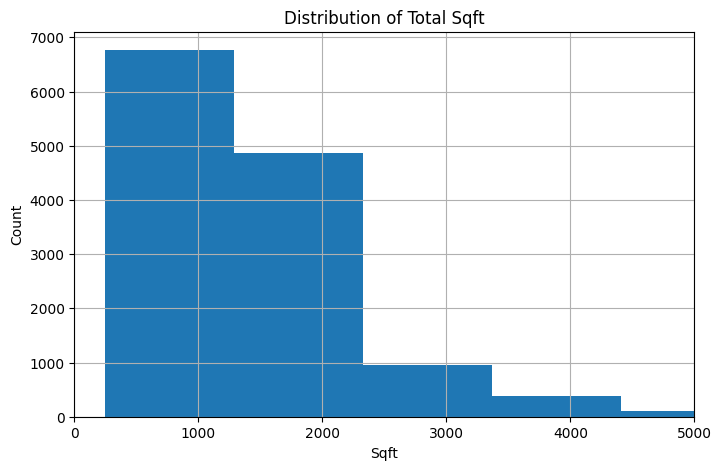

In [15]:
plt.figure(figsize=(8,5))
df2['total_sqft_num'].hist(bins=50)
plt.title("Distribution of Total Sqft")
plt.xlabel("Sqft")
plt.ylabel("Count")
plt.xlim(0, df2['total_sqft_num'].quantile(0.99)) # trim top 1%
plt.show()

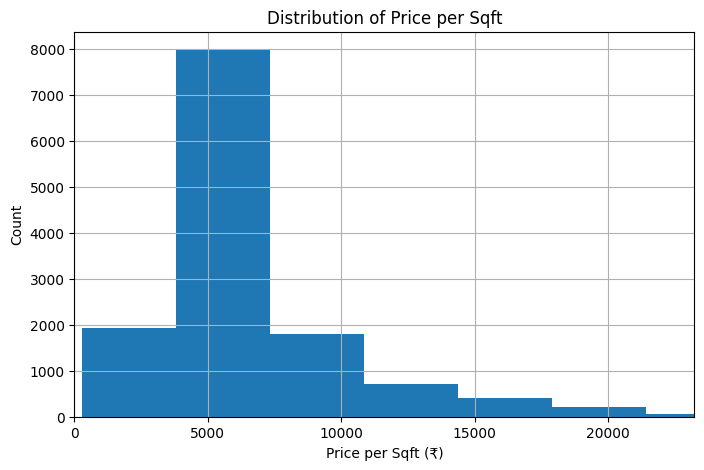

In [16]:
plt.figure(figsize=(8,5))
df2['price_per_sqft'].hist(bins=50)
plt.title("Distribution of Price per Sqft")
plt.xlabel("Price per Sqft (₹)")
plt.ylabel("Count")
plt.xlim(0, df2['price_per_sqft'].quantile(0.99)) # trim top 1%
plt.show()

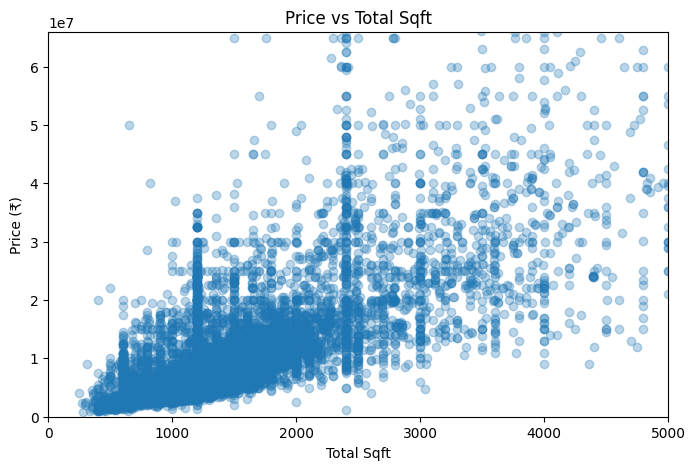

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df2['total_sqft_num'], df2['price']*100000, alpha=0.3)
plt.title("Price vs Total Sqft")
plt.xlabel("Total Sqft")
plt.ylabel("Price (₹)")
plt.xlim(0, df2['total_sqft_num'].quantile(0.99))
plt.ylim(0, df2['price'].quantile(0.99)*100000)
plt.show()

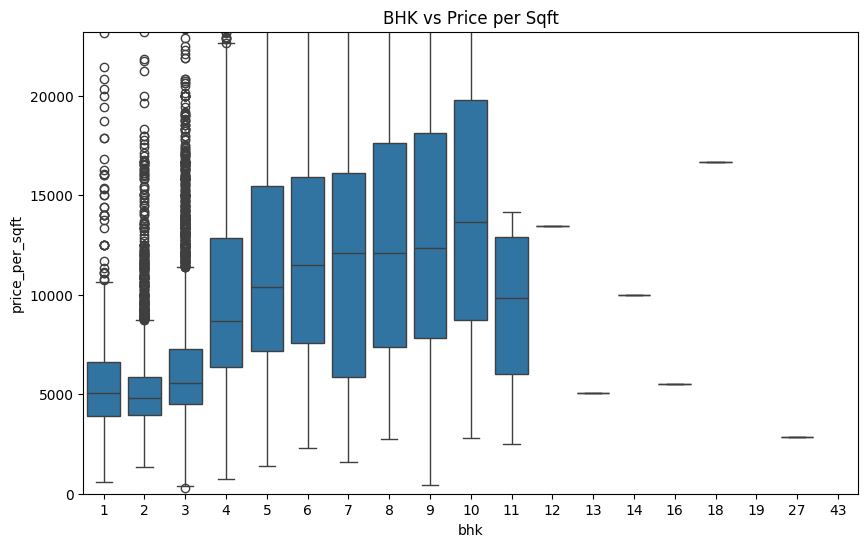

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(x='bhk', y='price_per_sqft', data=df2)
plt.title("BHK vs Price per Sqft")
plt.ylim(0, df2['price_per_sqft'].quantile(0.99))
plt.show()

In [19]:
df2['location'] = df2['location'].fillna('Unknown').apply(lambda x: x.strip())
print("Unique locations:", len(df2['location'].unique()))

Unique locations: 1286


In [20]:
location_counts = df2['location'].value_counts()
print(location_counts)

location
Whitefield               532
Sarjapur  Road           391
Electronic City          304
Kanakpura Road           264
Thanisandra              235
                        ... 
Kanakapura main  Road      1
Zuzuvadi                   1
Chellikere                 1
Jakkasandra                1
Gulakamale                 1
Name: count, Length: 1286, dtype: int64


In [21]:
rare_locations = location_counts[location_counts <= 10].index
print(rare_locations)

Index(['Ganga Nagar', 'Basapura', 'Sector 1 HSR Layout', 'Nagadevanahalli',
       '1st Block Koramangala', 'Dodsworth Layout', 'Gunjur Palya',
       'Thyagaraja Nagar', 'Nagappa Reddy Layout', 'Naganathapura',
       ...
       'Halanayakanahalli', 'Chikkanahalli', 'Kanakapur main road',
       'Sindhi Colony', 'Masjid e Alkareem', 'Kanakapura main  Road',
       'Zuzuvadi', 'Chellikere', 'Jakkasandra', 'Gulakamale'],
      dtype='object', name='location', length=1046)


In [22]:
df2['location'] = df2['location'].apply(lambda x: 'other' if x in rare_locations else x)
print("Unique locations after grouping rare ones:", len(df2['location'].unique()))

Unique locations after grouping rare ones: 241


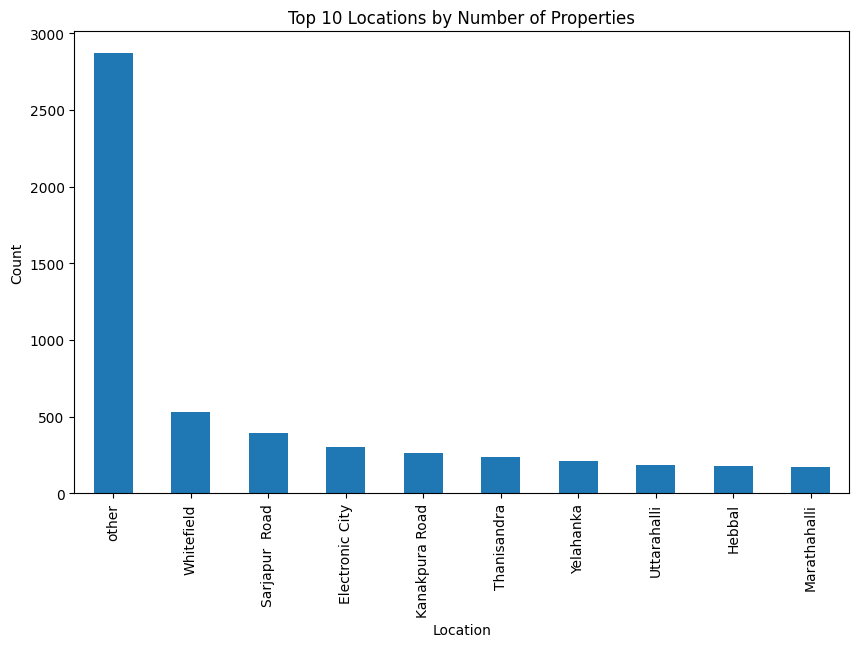

In [23]:
top_locations = df2['location'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_locations.plot(kind='bar')
plt.title("Top 10 Locations by Number of Properties")
plt.xlabel("Location")
plt.ylabel("Count")
plt.show()


Shape after price_per_sqft filtering: (13072, 8)


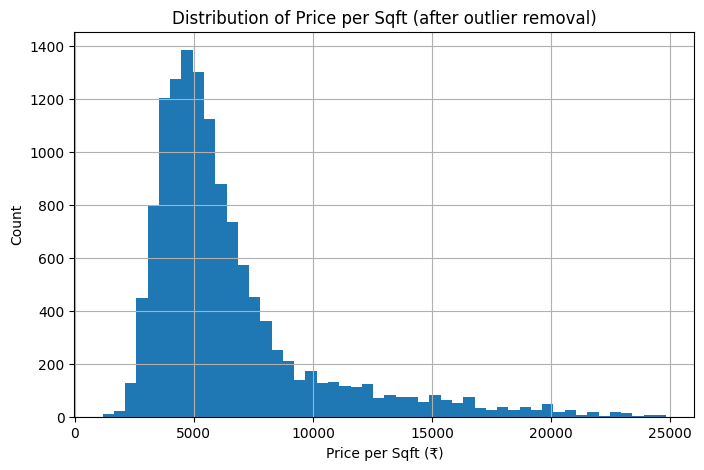

In [24]:
# Remove extreme price_per_sqft outliers
df2 = df2[(df2['price_per_sqft'] > 1000) & (df2['price_per_sqft'] < 25000)]
print("Shape after price_per_sqft filtering:", df2.shape)

# Plot again after filtering
plt.figure(figsize=(8,5))
df2['price_per_sqft'].hist(bins=50)
plt.title("Distribution of Price per Sqft (after outlier removal)")
plt.xlabel("Price per Sqft (₹)")
plt.ylabel("Count")
plt.show()

In [25]:
df2[df2.total_sqft_num/df2.bhk < 300].head()

,location,size,total_sqft,bath,price,bhk,total_sqft_num,price_per_sqft
58,Murugeshpalya,6 Bedroom,1407,4.0,150.0,6,1407.0,10660.980810
68,Devarachikkanahalli,8 Bedroom,1350,7.0,85.0,8,1350.0,6296.296296
70,other,3 Bedroom,500,3.0,100.0,3,500.0,20000.000000
78,Kaval Byrasandra,2 BHK,460,1.0,22.0,2,460.0,4782.608696
89,Rajaji Nagar,6 Bedroom,710,6.0,160.0,6,710.0,22535.211268


In [26]:
df3 = df2[~(df2.total_sqft_num/df2.bhk < 300)]
df3.head(10)

,location,size,total_sqft,bath,price,bhk,total_sqft_num,price_per_sqft
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2,1056.0,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4,2600.0,4615.384615
2,Uttarahalli,3 BHK,1440,2.0,62.00,3,1440.0,4305.555556
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3,1521.0,6245.890861
4,Kothanur,2 BHK,1200,2.0,51.00,2,1200.0,4250.000000
5,Whitefield,2 BHK,1170,2.0,38.00,2,1170.0,3247.863248
6,Old Airport Road,4 BHK,2732,4.0,204.00,4,2732.0,7467.057101
7,Rajaji Nagar,4 BHK,3300,4.0,600.00,4,3300.0,18181.818182
8,Marathahalli,3 BHK,1310,3.0,63.25,3,1310.0,4828.244275
10,Whitefield,3 BHK,1800,2.0,70.00,3,1800.0,3888.888889


In [27]:
df3.shape

(12359, 8)

In [28]:
def remove_outliers_std(df, column):
    mean_val = df[column].mean()
    std_val = df[column].std()
    return df[(df[column] > (mean_val - 2*std_val)) & 
              (df[column] < (mean_val + 2*std_val))]


In [29]:
print("Before:", df3.shape)
df3 = remove_outliers_std(df3, 'price_per_sqft')
print("After:", df3.shape)

Before: (12359, 8)
After: (11677, 8)


<Axes: xlabel='price_per_sqft', ylabel='Count'>

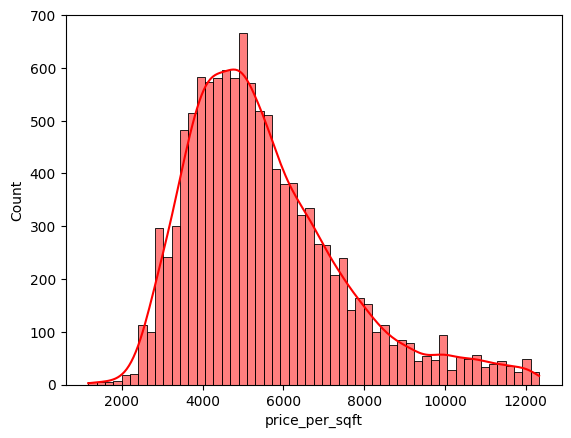

In [30]:
sns.histplot(data = df3, x = 'price_per_sqft',kde = True, color = 'red')

<Axes: xlabel='price_per_sqft', ylabel='Count'>

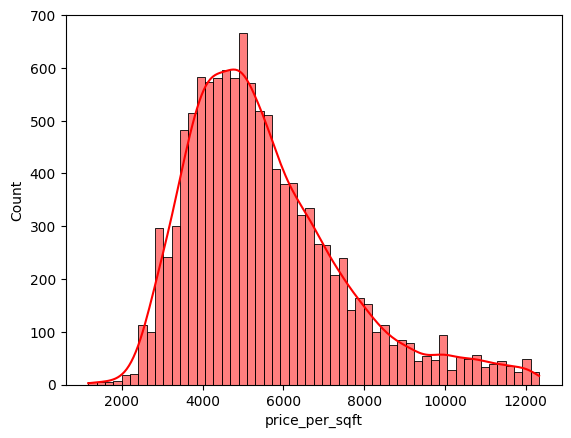

In [31]:
sns.histplot(data = df3, x = 'price_per_sqft',kde = True, color = 'red')

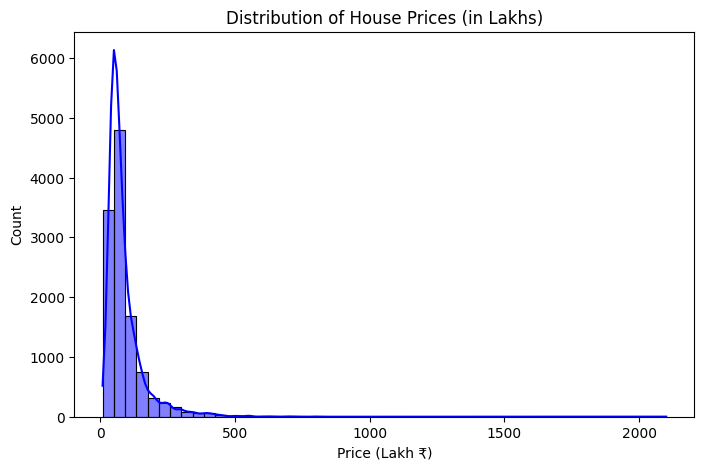

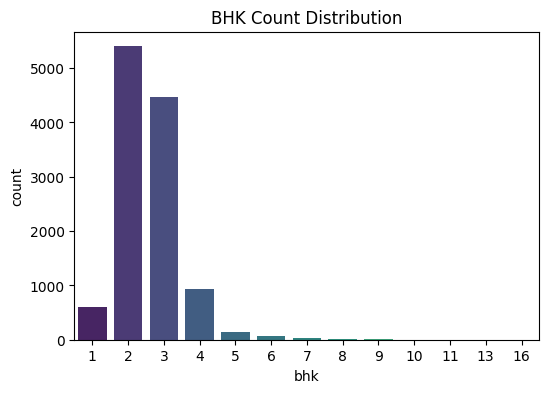

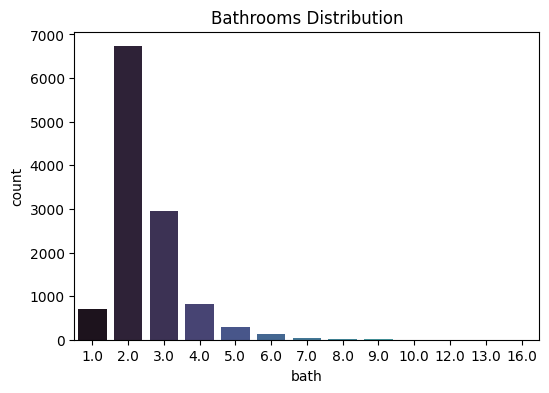

In [32]:
# Price distribution
plt.figure(figsize=(8,5))
sns.histplot(df3['price'], bins=50, kde=True, color="blue")
plt.title("Distribution of House Prices (in Lakhs)")
plt.xlabel("Price (Lakh ₹)")
plt.show()

# BHK distribution
plt.figure(figsize=(6,4))
sns.countplot(x='bhk', data=df3, palette="viridis")
plt.title("BHK Count Distribution")
plt.show()

# Bathrooms
plt.figure(figsize=(6,4))
sns.countplot(x='bath', data=df3, palette="mako")
plt.title("Bathrooms Distribution")
plt.show()


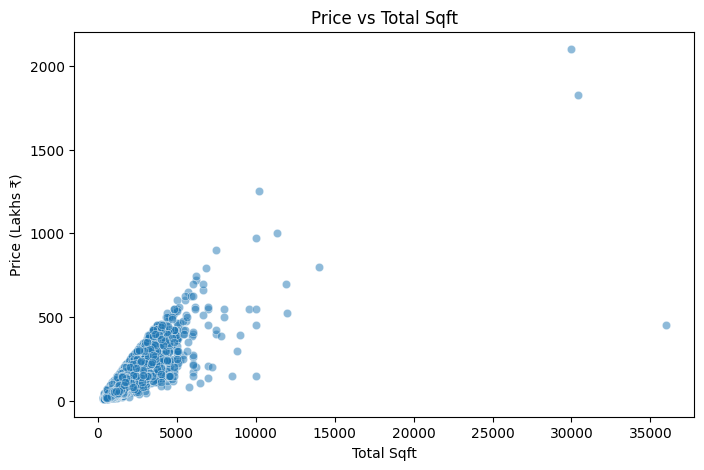

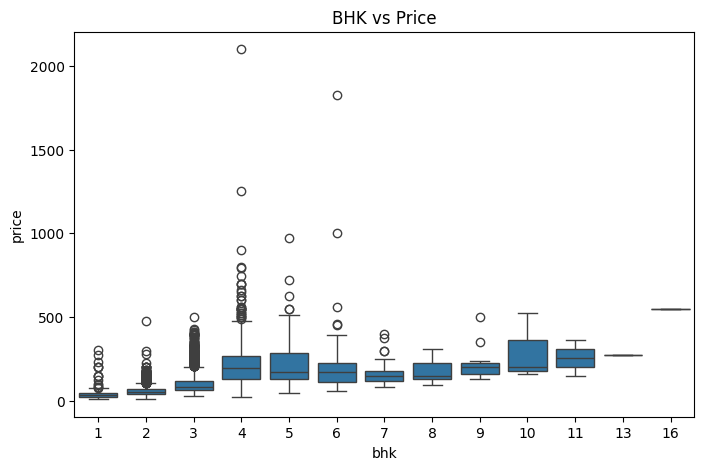

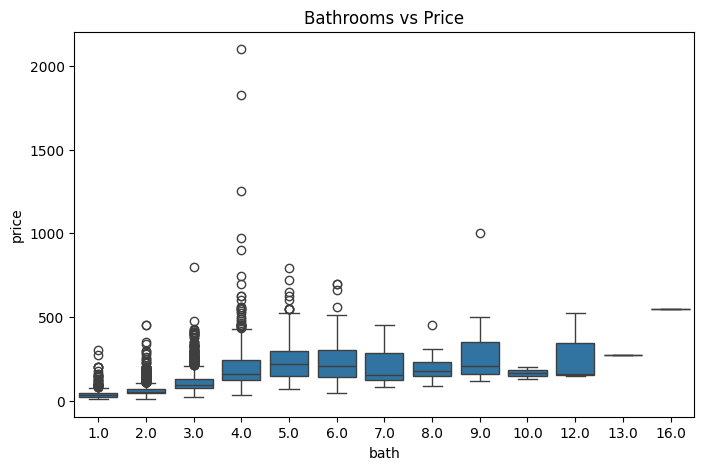

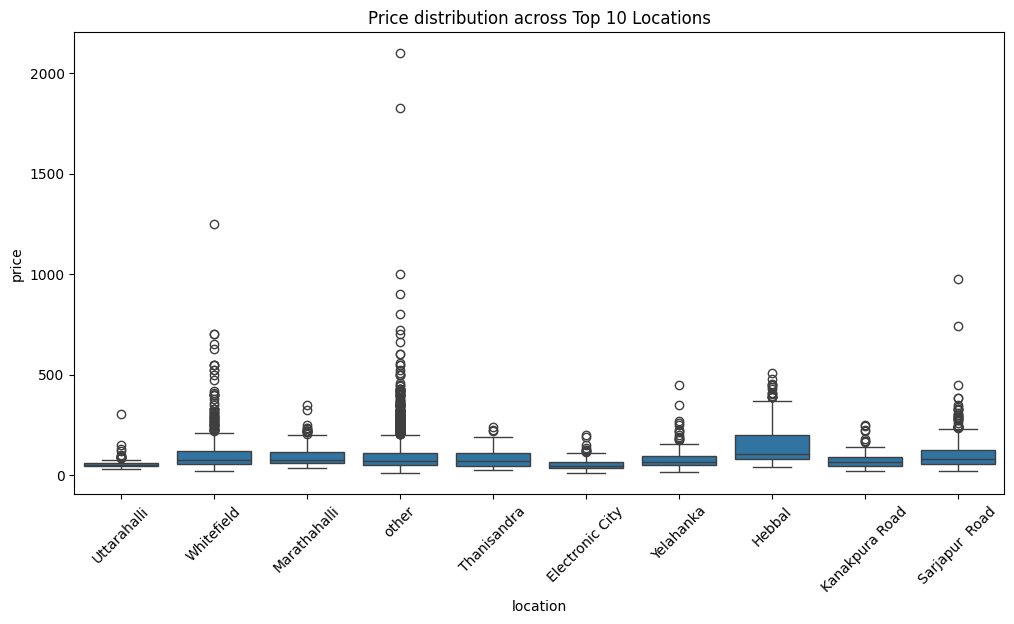

In [33]:
# Price vs Sqft (scatter)
plt.figure(figsize=(8,5))
sns.scatterplot(x='total_sqft_num', y='price', data=df3, alpha=0.5)
plt.title("Price vs Total Sqft")
plt.xlabel("Total Sqft")
plt.ylabel("Price (Lakhs ₹)")
plt.show()

# BHK vs Price
plt.figure(figsize=(8,5))
sns.boxplot(x='bhk', y='price', data=df3)
plt.title("BHK vs Price")
plt.show()

# Bathrooms vs Price
plt.figure(figsize=(8,5))
sns.boxplot(x='bath', y='price', data=df3)
plt.title("Bathrooms vs Price")
plt.show()

# Location vs Price (Top 10)
top_locs = df2['location'].value_counts().head(10).index
plt.figure(figsize=(12,6))
sns.boxplot(x='location', y='price', data=df3[df3['location'].isin(top_locs)])
plt.xticks(rotation=45)
plt.title("Price distribution across Top 10 Locations")
plt.show()


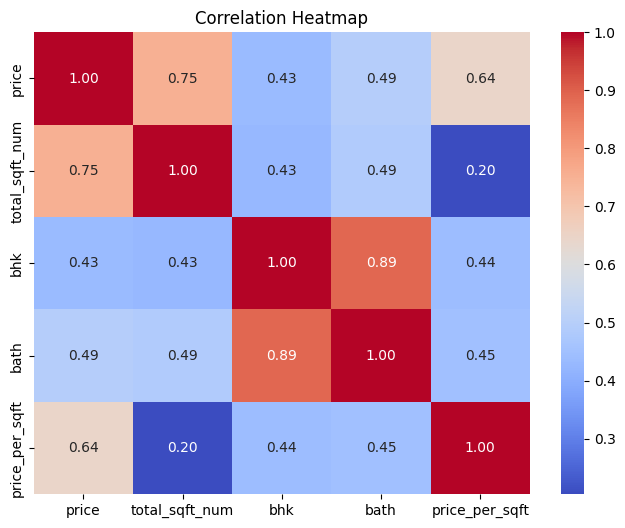

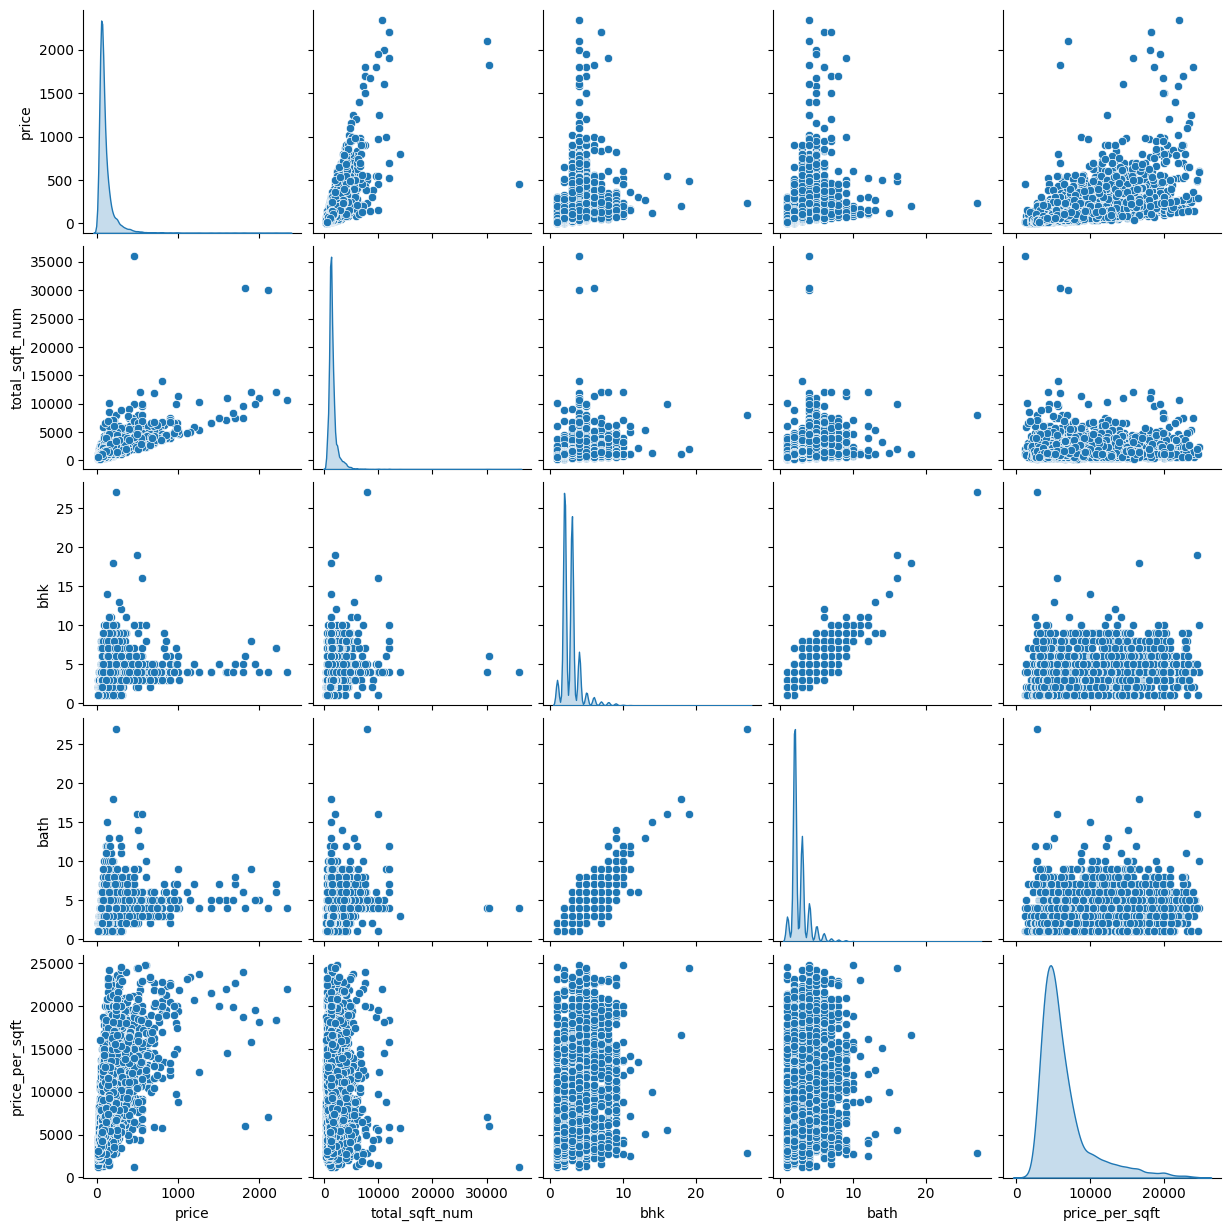

In [34]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df2[['price','total_sqft_num','bhk','bath','price_per_sqft']].corr(), 
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Pairplot
sns.pairplot(df2[['price','total_sqft_num','bhk','bath','price_per_sqft']], diag_kind="kde")
plt.show()


In [35]:
df3

,location,size,total_sqft,bath,price,bhk,total_sqft_num,price_per_sqft
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2,1056.0,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4,2600.0,4615.384615
2,Uttarahalli,3 BHK,1440,2.0,62.00,3,1440.0,4305.555556
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3,1521.0,6245.890861
4,Kothanur,2 BHK,1200,2.0,51.00,2,1200.0,4250.000000
...,...,...,...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00,5,3453.0,6689.834926
13316,other,4 BHK,3600,5.0,400.00,4,3600.0,11111.111111
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00,2,1141.0,5258.545136
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00,4,4689.0,10407.336319


In [36]:
# Select features
df_model = df3[['location', 'total_sqft_num', 'bath', 'bhk', 'price']]

In [37]:
df_model = pd.get_dummies(df_model, columns=['location'], drop_first=True ,dtype=int)

In [38]:
df_model

,total_sqft_num,bath,bhk,price,location_1st Phase JP Nagar,location_2nd Phase Judicial Layout,location_2nd Stage Nagarbhavi,location_5th Block Hbr Layout,location_5th Phase JP Nagar,location_6th Phase JP Nagar,...,location_Vishveshwarya Layout,location_Vishwapriya Layout,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
0,1056.0,2.0,2,39.07,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2600.0,5.0,4,120.00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1440.0,2.0,3,62.00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1521.0,3.0,3,95.00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1200.0,2.0,2,51.00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13315,3453.0,4.0,5,231.00,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
13316,3600.0,5.0,4,400.00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
13317,1141.0,2.0,2,60.00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13318,4689.0,4.0,4,488.00,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
X = df_model.drop('price', axis=1)
y = df_model['price']

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Scale numeric features for Linear Regression
numeric_cols = ['total_sqft_num', 'bath', 'bhk']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Predict and evaluate
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse)
print("Linear Regression R2:", r2)

Linear Regression RMSE: 36.925528293101735
Linear Regression R2: 0.7493228074600174


In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score
# Train Random Forest Regressor (no need to scale features)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse)
print("Random Forest MAE:", mae)
print("Random Forest R2:", r2)

Random Forest RMSE: 35.80141419795928
Random Forest MAE: 19.122967596344967
Random Forest R2: 0.7643530888197418


In [50]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse)
print("XGBoost MAE:", mae)
print("XGBoost R2:", r2)


XGBoost RMSE: 59.78436821309933
XGBoost MAE: 21.63069545845463
XGBoost R2: 0.3428921197932261


In [51]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse)
print("XGBoost MAE:", mae)
print("XGBoost R2:", r2)


XGBoost RMSE: 57.19401580346001
XGBoost MAE: 21.872668927026123
XGBoost R2: 0.3986011832354438
